In [1]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#load data from hugginface datasets
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter for US Data Analyst Roles

In [2]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

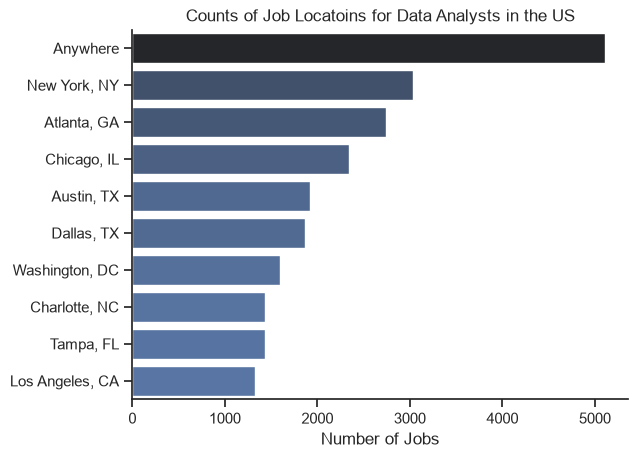

In [12]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style = 'ticks')
sns.barplot(df_plot, x= 'count', y= 'job_location', hue = 'count', palette='dark:b_r', legend = False)
sns.despine()
plt.title('Counts of Job Locatoins for Data Analysts in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

## Top 5 Data Analyst Skills by month
#### using explode and pivot tables

In [18]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
df_DA_explode = df_DA.explode('job_skills')

df_DA_explode.pivot_table(index='job_posted_month_no', columns = 'job_skills', aggfunc='size', fill_value=0)
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no',columns = 'job_skills', aggfunc='size',fill_value=0)
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot= df_DA_pivot.drop('Total')

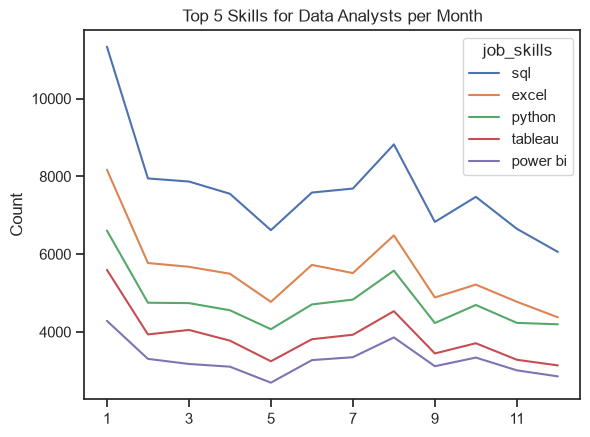

In [19]:
df_DA_pivot.iloc[:,:5].plot(kind="line")
plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

## True / False Pie charts for Data Analyst Jobs that 
### [ Work from Home, Require a degree or Offer Health Insurance ]

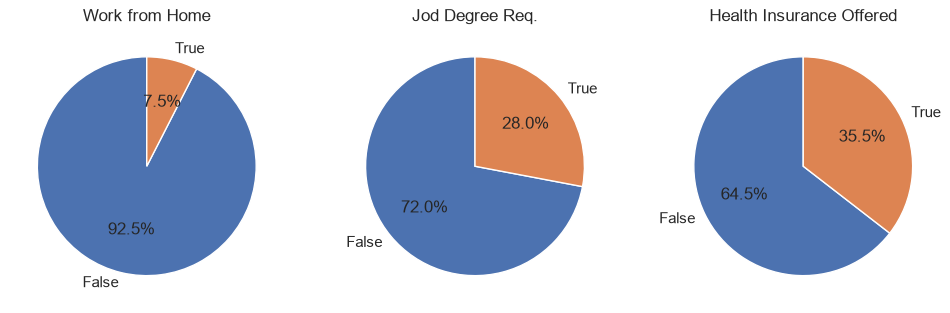

In [15]:

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Jod Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i,(column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['False','True'])
    ax[i].set_title(title)

plt.show()

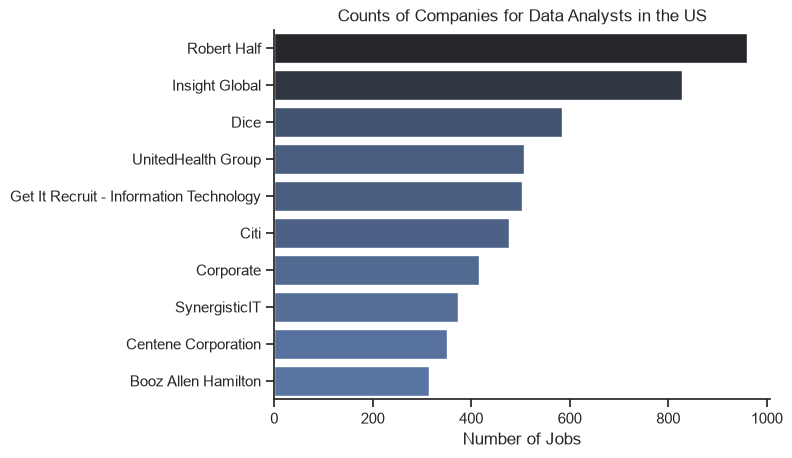

In [16]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()


sns.set_theme(style = 'ticks')
sns.barplot(df_plot, x= 'count', y= 'company_name', hue = 'count', palette='dark:b_r', legend = False)
sns.despine()
plt.title('Counts of Companies for Data Analysts in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()